# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.6 MB/s eta 0:00:00


In [2]:
import pandas as pd  # Library for data manipulation and analysis.
import numpy as np   # Fundamental package for scientific computing.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

from sklearn.model_selection import train_test_split  # Function for splitting datasets for training and testing.

import time  # Module for time-related operations.

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense,Dropout,BatchNormalization   # for creating fully connected neural network layers.
from sklearn import metrics

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [3]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')
data_train = pd.read_csv('Train.csv')
data_test = pd.read_csv('Test.csv')

# **Data Overview**

In [4]:
data_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [5]:
data_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


In [6]:
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


In [7]:
data_train.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [8]:
data_test.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


Observation:
1) The data is ciphered and it is not possible to understand the physical interpretations of the features.
2) There are some missing values. We could consider removing those rows or replacing them with the mean.

# **Exploratory Data Analysis**

## Univariate analysis

<Axes: xlabel='Target', ylabel='count'>

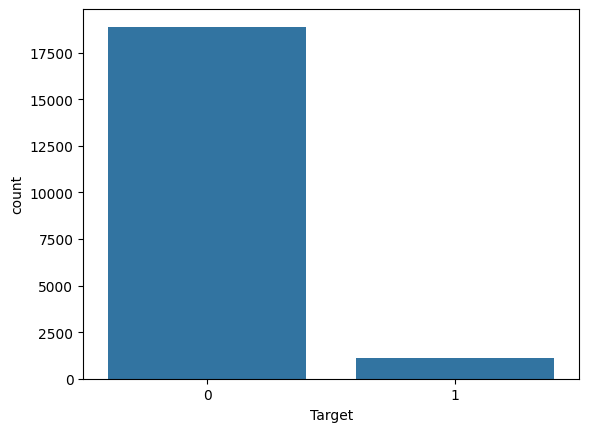

In [9]:
sns.countplot(x='Target', data=data_train)

<Axes: xlabel='Target', ylabel='count'>

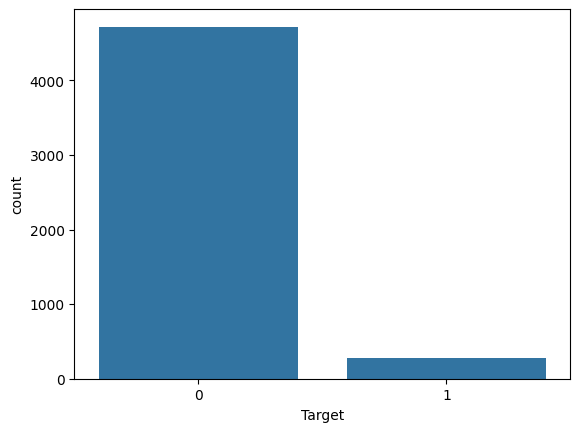

In [10]:
sns.countplot(x='Target', data=data_test)

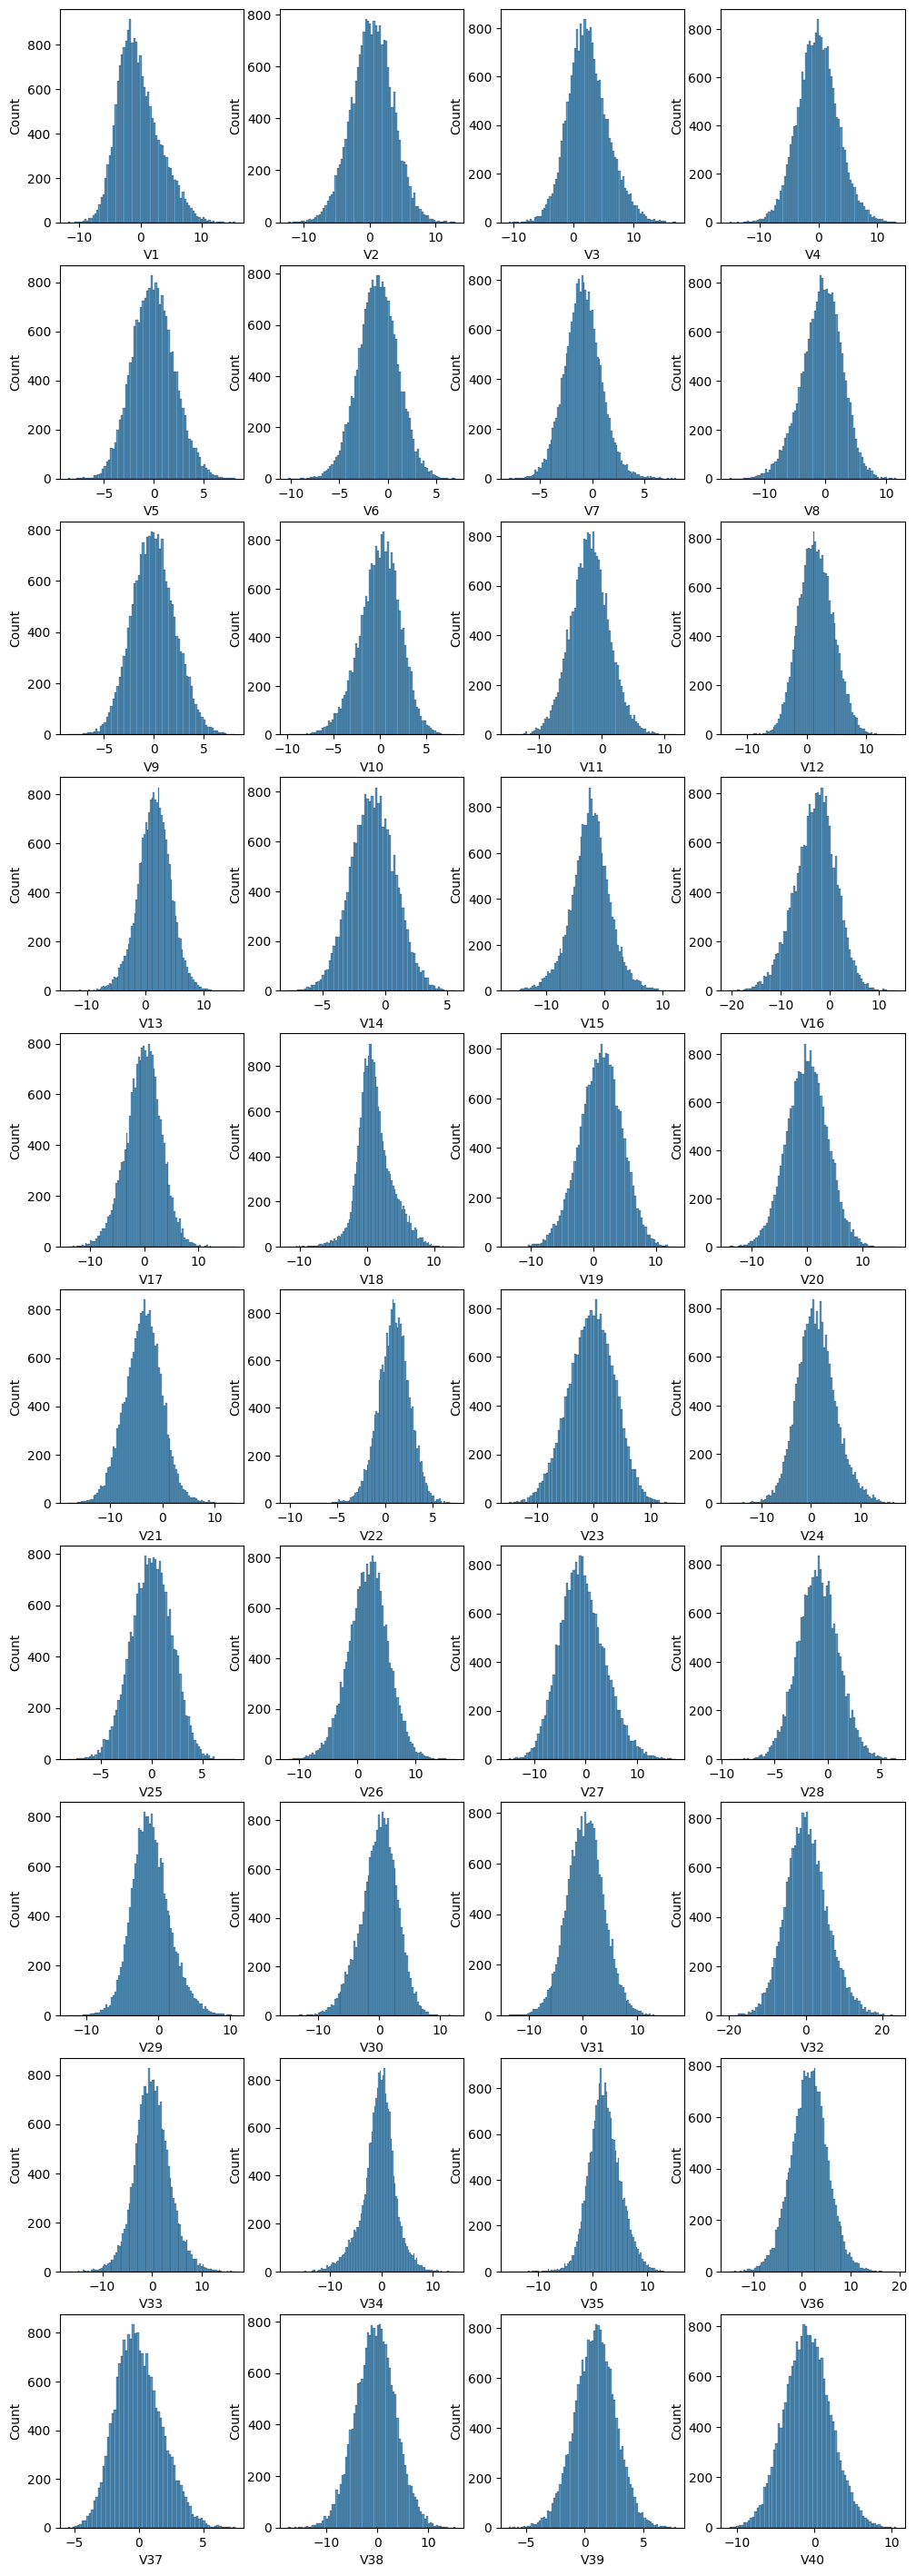

In [11]:
# Creating subplots with multiple histograms for train data
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(12, 36))

for i in range(0,40):
    sns.histplot(x=f'V{i+1}', data=data_train, ax=axes[i//4, i%4])

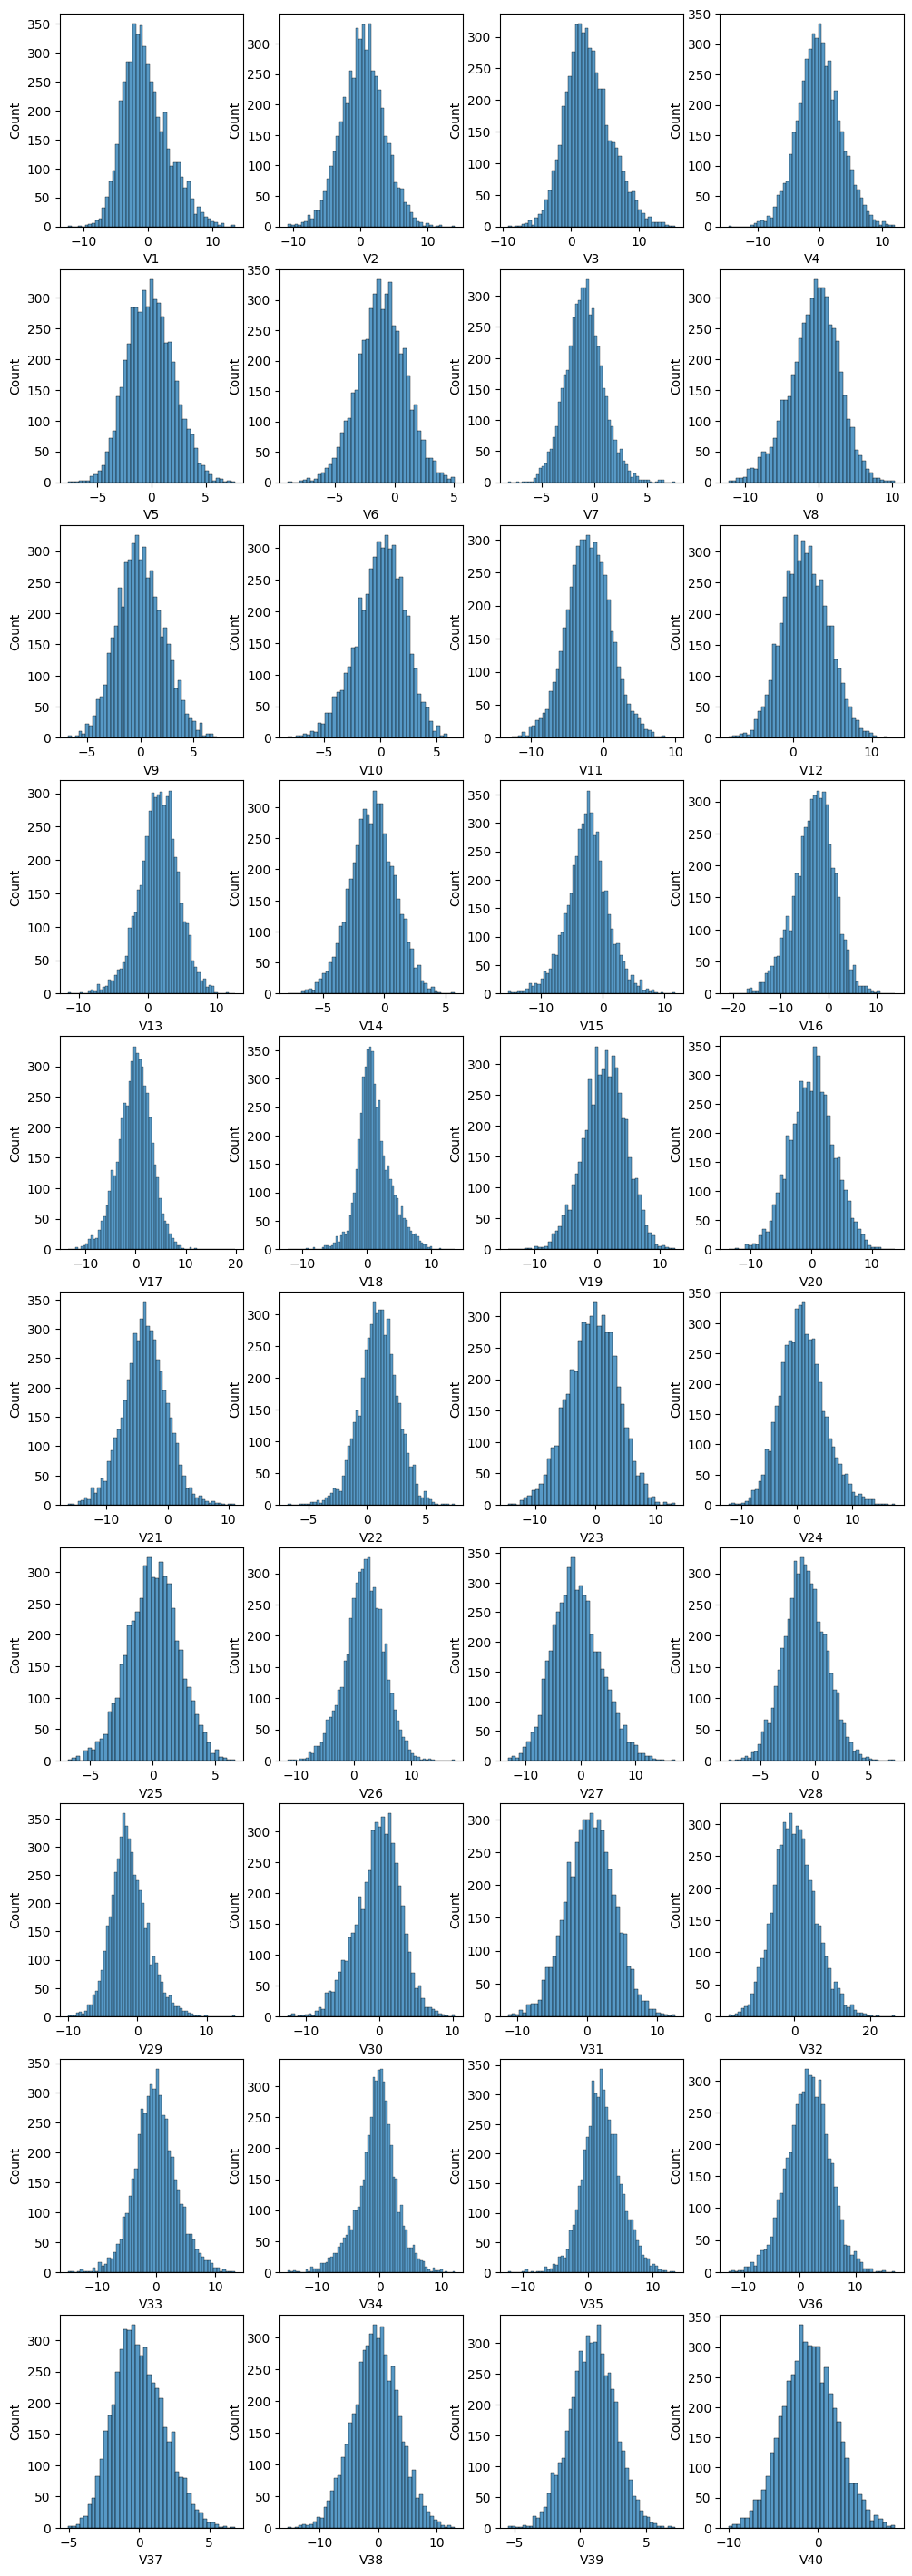

In [12]:
# Creating subplots with multiple histograms for test data
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(12, 36))

for i in range(0,40):
    sns.histplot(x=f'V{i+1}', data=data_test, ax=axes[i//4, i%4])

Observations:
1) All 40 of the independent varialbes look normally distributed. Some of them have a skewness.
2) We know that there are some missing values in V1 and V2. To impute those with the mean or median will be a good idea since they are normally distributed.
3) The test data has a similar distribution of the target variable as the train data.

## Bivariate Analysis

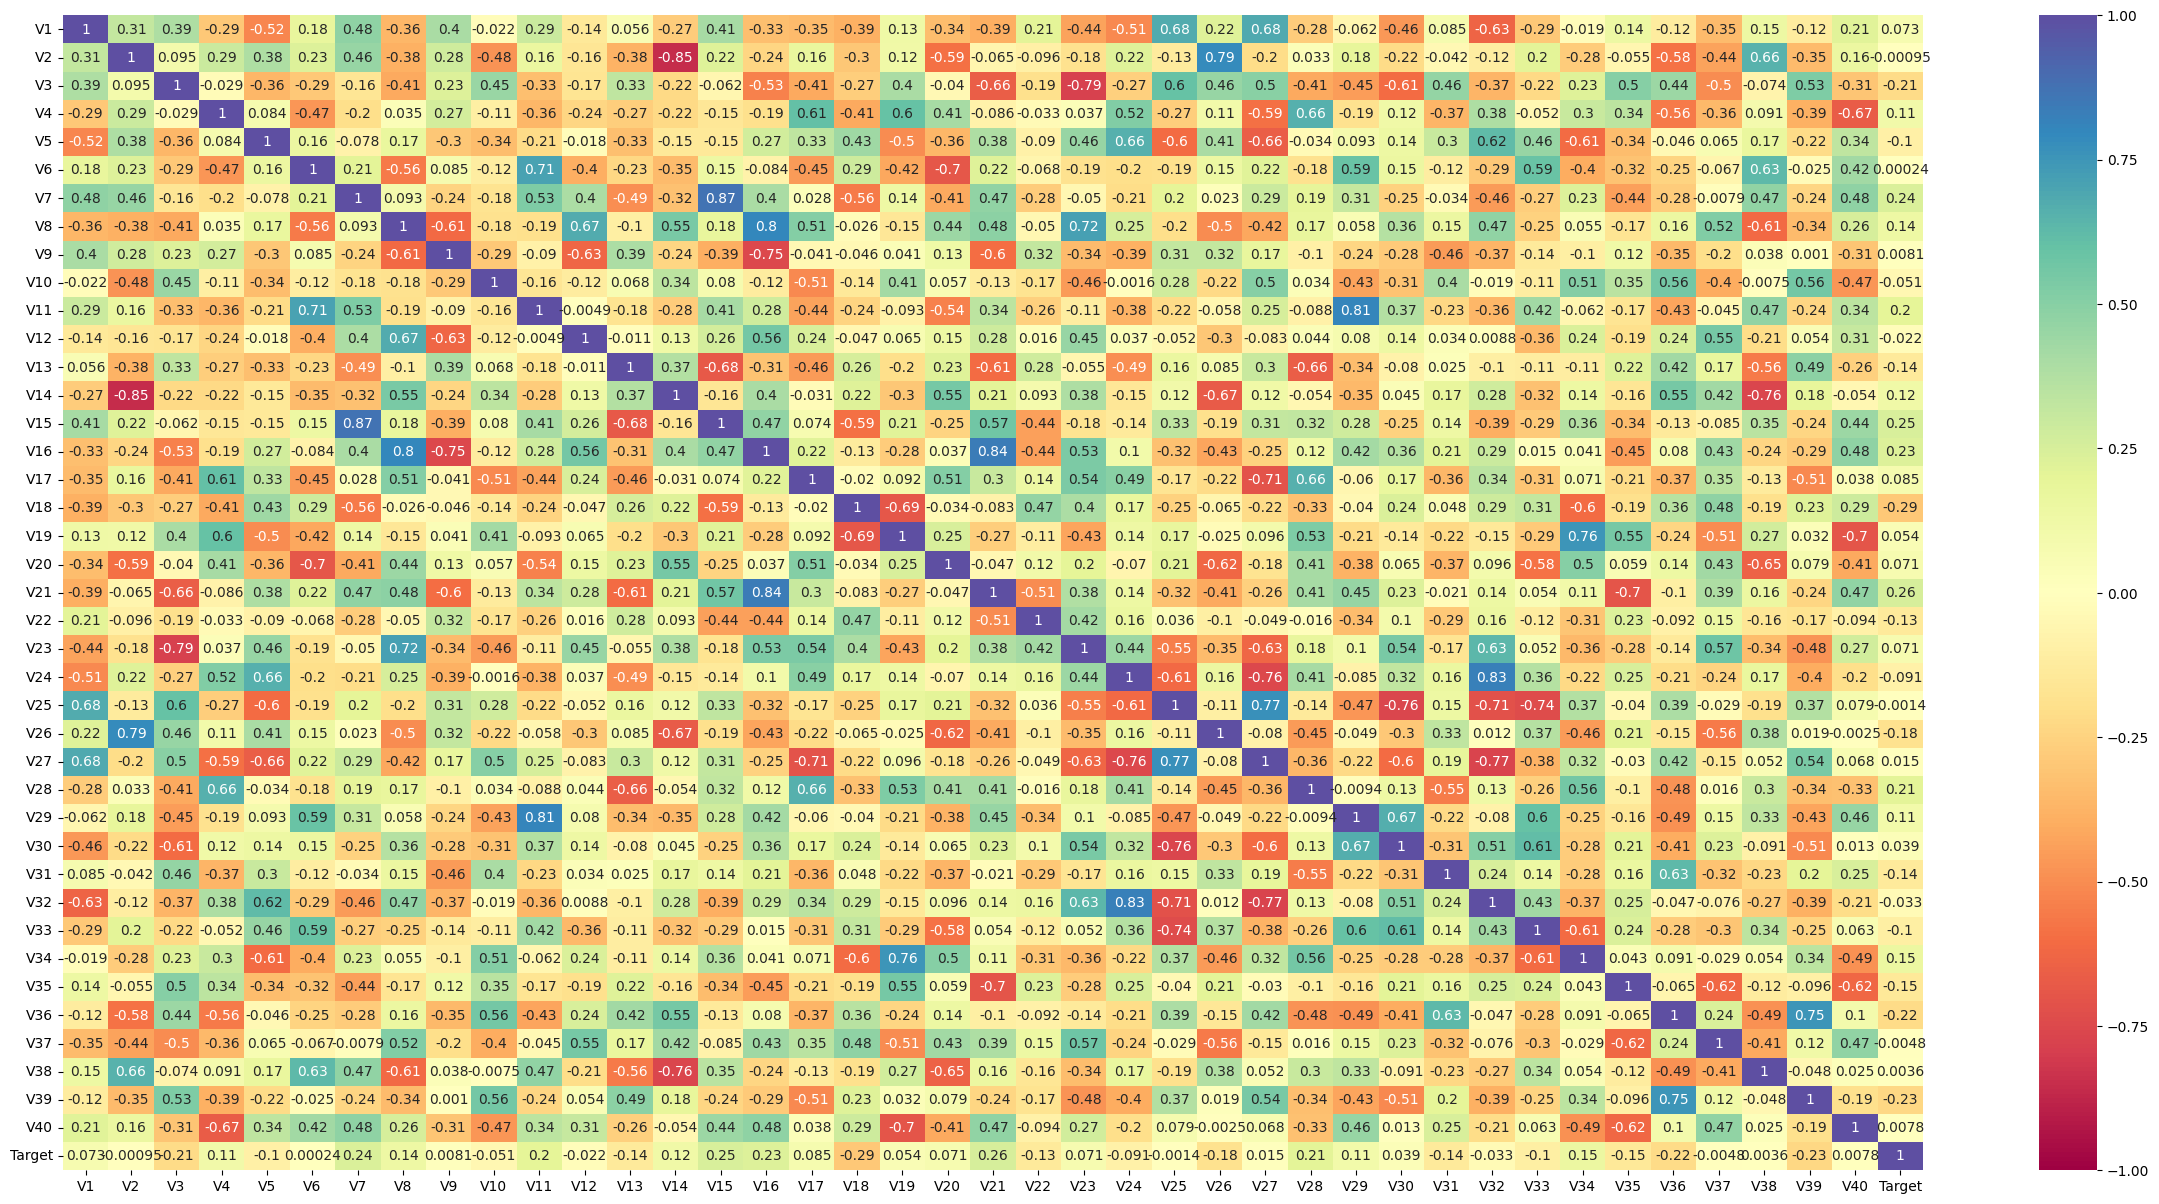

In [13]:
plt.figure(figsize=(30,15))
sns.heatmap(data_train.corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.show()

Observations:
1) Some variables have a stronger prediction power on the Target variable. Many of whom are negatively correlated with target.
2) Without an understanding of the physical meaning of those variables we can't make any conclusions. Fortunately we don't need to check for that in Neural Networks.

# **Data Preprocessing**

To start with data process. I will keep a copy of the dataset in a different df and label those as X,y.

In [14]:
X_train = data_train.drop('Target', axis=1)
y_train = data_train['Target']
X_test = data_test.drop('Target', axis=1)
y_test = data_test['Target']

In [15]:
X_train.isnull().sum()[['V1','V2']]

,0
V1,18
V2,18


In [16]:
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

In [17]:
X_train.isnull().sum()[['V1','V2']]

,0
V1,0
V2,0


In [117]:
X_train.isduplicated().sum()

AttributeError: 'DataFrame' object has no attribute 'isduplicated'

# **Model Building**

## Model Evaluation Criterion

Write down the model evaluation criterion with rationale

In [18]:
batch_size = 32
epochs = 50
num_classes = 1

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [19]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [20]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [21]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [22]:
#Initializing the neural network
model_0 = Sequential()
model_0.add(Dense(128,activation="relu",input_dim = X_train.shape[1]))
model_0.add(Dense(num_classes,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
optimizer = keras.optimizers.SGD()    # defining SGD as the optimizer to be used
loss=keras.losses.BinaryCrossentropy()
model_0.compile(loss=loss, optimizer=optimizer, metrics=["recall"])

In [25]:
start = time.time()
history = model_0.fit(X_train, y_train, validation_split = 0.2 , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1228 - recall: 0.4807 - val_loss: 0.1004 - val_recall: 0.5913
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0867 - recall: 0.6602 - val_loss: 0.0865 - val_recall: 0.7000
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0771 - recall: 0.7193 - val_loss: 0.0799 - val_recall: 0.7130
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0717 - recall: 0.7432 - val_loss: 0.0745 - val_recall: 0.7435
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0679 - recall: 0.7580 - val_loss: 0.0709 - val_recall: 0.7652
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0652 - recall: 0.7830 - val_loss: 0.0697 - val_recall: 0.7304
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0631 - recall: 0.7852 - val_loss: 0.0673 - val_recall: 0.7391
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0614 - recall: 0.7932 - val_loss: 0.0654 - val_recall: 0.7652
Epoch 9/

In [26]:
print("Time taken in seconds ",end-start)

Time taken in seconds  66.0994040966034


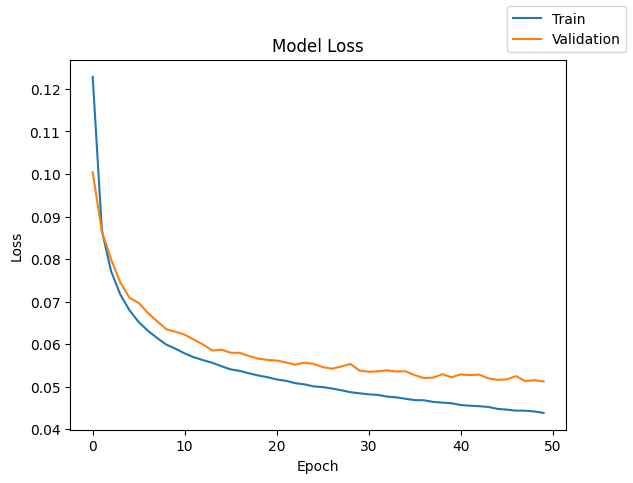

In [27]:
plot(history,'loss')

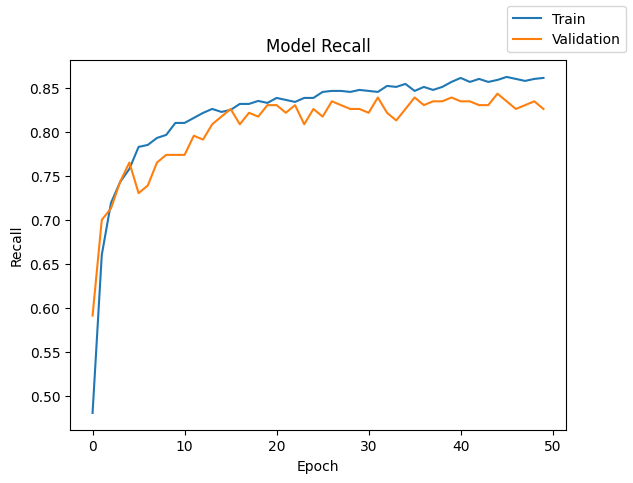

In [28]:
plot(history,'recall')

In [29]:
#Defining the columns of the dataframe which are nothing but the hyper parameters and the metrics.
columns = ["# hidden layers","# neurons - hidden layer","activation function - hidden layer ","# epochs","batch size","optimizer","learning rate, momentum","weight initializer","regularization","train loss","validation loss","train recall","validation recall","time (secs)"]

#Creating a pandas dataframe.
results = pd.DataFrame(columns=columns)

In [30]:
model_0.get_layer(index=0).get_config()

{'name': 'dense',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'units': 128,
 'activation': 'relu',
 'use_bias': True,
 'kernel_initializer': {'module': 'keras.initializers',
  'class_name': 'GlorotUniform',
  'config': {'seed': None},
  'registered_name': None},
 'bias_initializer': {'module': 'keras.initializers',
  'class_name': 'Zeros',
  'config': {},
  'registered_name': None},
 'kernel_regularizer': None,
 'bias_regularizer': None,
 'kernel_constraint': None,
 'bias_constraint': None,
 'quantization_config': None}

In [31]:
results.loc[0] = [1,[128],["relu"],50,32,"sgd",[0.01, "-"],"glorot uniform","-",history.history["loss"][-1],history.history["val_loss"][-1],history.history["recall"][-1],history.history["val_recall"][-1],round(end-start,2)]

In [32]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,[128],[relu],50,32,sgd,"[0.01, -]",glorot uniform,-,0.04381,0.051187,0.861364,0.826087,66.1


To better understand the predictions we can round them and compare with the true values. This way we can create the confusion matrix.

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Axes: ylabel='Count'>

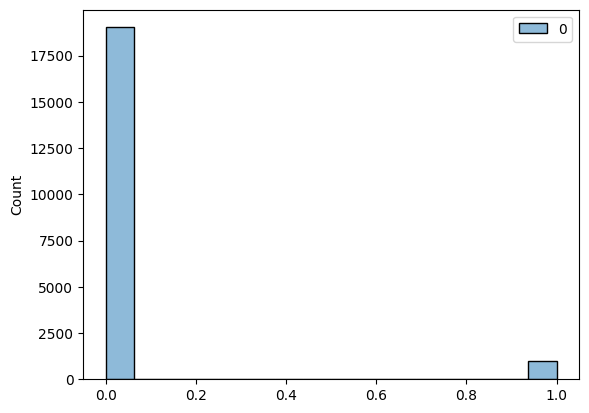

In [33]:
prediction = model_0.predict(X_train)
prediction_rounded = np.round(prediction, decimals = 0)
sns.histplot(prediction_rounded)

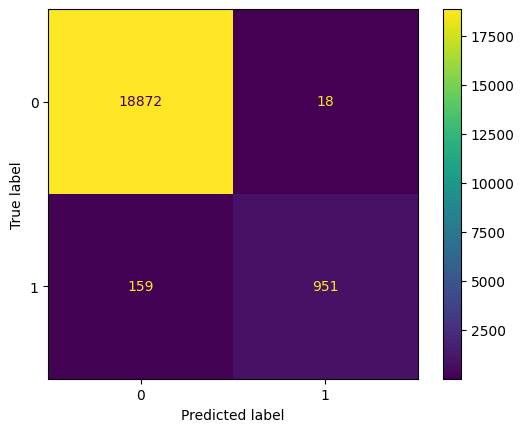

In [34]:
confusion_matrix = metrics.confusion_matrix(y_train, prediction_rounded, labels=[0, 1])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

Observations:
1) The validation recall score for model 0 is at 0.839 which is a good start. So we are able to identify  83.9% of the true positive.
2) This hasn't come with a loss in precision since the majority are still predicted to be '0' which is consistent with the distribution. Precision is 959/(959+14) which is more than 98.5%.
3) Although there is a class imbalance, the model isn't preferring the majority class.
4) The Validation loss oscillates towards the end which suggests that the learning rate is too high. We should consider reducing the learning rate or using Adaptive Gradient or adam.

# **Model Performance Improvement**

## Model 1

TO start with we will try to reduce the learning rate and see if the model improves.

In [35]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [36]:
#Initializing the neural network
model_1 = Sequential()
model_1.add(Dense(128,activation="relu",input_dim = X_train.shape[1]))
model_1.add(Dense(num_classes,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
learning_rate = 0.001

In [38]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
optimizer = keras.optimizers.SGD(learning_rate=learning_rate)    # defining SGD as the optimizer to be used
model_1.compile(loss=loss, optimizer=optimizer, metrics=["recall"])

In [40]:
start = time.time()
history = model_1.fit(X_train, y_train, validation_split = 0.2 , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2177 - recall: 0.1761 - val_loss: 0.1775 - val_recall: 0.2174
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1565 - recall: 0.2841 - val_loss: 0.1493 - val_recall: 0.3174
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1347 - recall: 0.3795 - val_loss: 0.1338 - val_recall: 0.4130
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1220 - recall: 0.4580 - val_loss: 0.1243 - val_recall: 0.4435
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1136 - recall: 0.5011 - val_loss: 0.1176 - val_recall: 0.4826
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1077 - recall: 0.5432 - val_loss: 0.1127 - val_recall: 0.5261
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1032 - recall: 0.5648 - val_loss: 0.1088 - val_recall: 0.5913
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0995 - recall: 0.5886 - val_loss: 0.1057 - val_recall: 0.6087
Epoch 9/

In [41]:
print("Time taken in seconds ",end-start)

Time taken in seconds  89.22863340377808


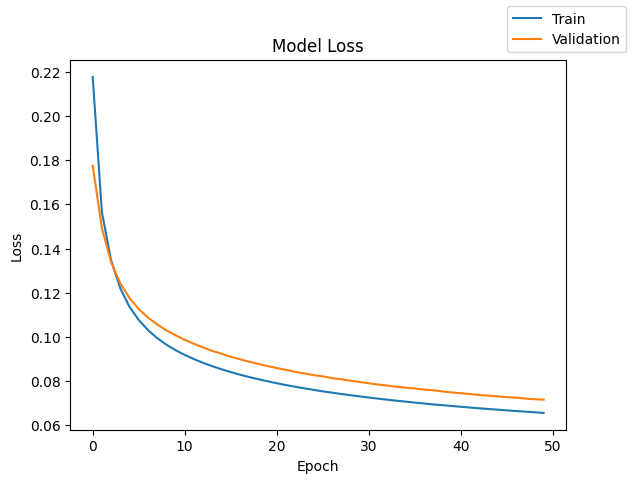

In [42]:
plot(history,'loss')

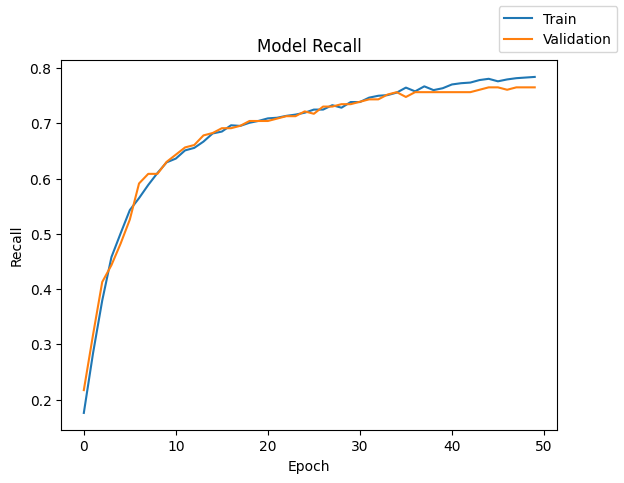

In [43]:
plot(history,'recall')

In [44]:
results.loc[1] = [1,[128],["relu"],50,32,"sgd",[0.001, "-"],"glorot uniform","-",history.history["loss"][-1],history.history["val_loss"][-1],history.history["recall"][-1],history.history["val_recall"][-1],round(end-start,2)]

In [45]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,[128],[relu],50,32,sgd,"[0.01, -]",glorot uniform,-,0.043810,0.051187,0.861364,0.826087,66.10
1,1,[128],[relu],50,32,sgd,"[0.001, -]",glorot uniform,-,0.065645,0.071659,0.784091,0.765217,89.23


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


<Axes: ylabel='Count'>

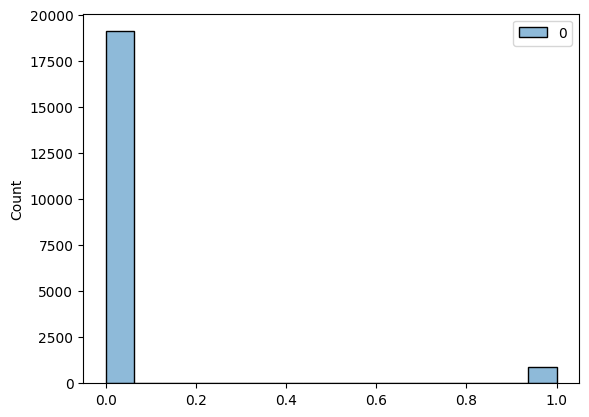

In [46]:
prediction = model_1.predict(X_train)
prediction_rounded = np.round(prediction, decimals = 0)
sns.histplot(prediction_rounded)

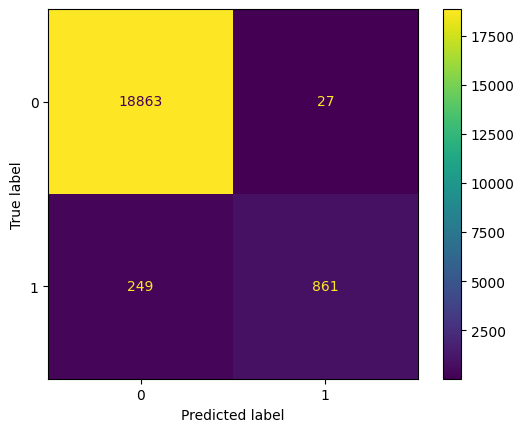

In [47]:
confusion_matrix = metrics.confusion_matrix(y_train, prediction_rounded, labels=[0, 1])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

Observations:
1) By reducing the learning rate the loss graph looks a lot smoother. Therefore 0.001 is perhaps a better learning rate.
2) The rate of convergence has slowed down as we would expect and the final model is underfit.
3) We could increase the model complexity to capture more information from the data.

## Model 2

We add a new hidden layer to the model of 64 neurons.

In [48]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [49]:
#Initializing the neural network
model_2 = Sequential()
model_2.add(Dense(128,activation="relu",input_dim = X_train.shape[1]))
model_2.add(Dense(64,activation="relu"))
model_2.add(Dense(num_classes,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
optimizer = keras.optimizers.SGD(learning_rate=learning_rate)    # defining SGD as the optimizer to be used
model_2.compile(loss=loss, optimizer=optimizer, metrics=["recall"])

In [52]:
start = time.time()
history = model_2.fit(X_train, y_train, validation_split = 0.2 , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2292 - recall: 0.2761 - val_loss: 0.1531 - val_recall: 0.2261
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1378 - recall: 0.3455 - val_loss: 0.1316 - val_recall: 0.3652
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1205 - recall: 0.4591 - val_loss: 0.1192 - val_recall: 0.4609
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1097 - recall: 0.5216 - val_loss: 0.1109 - val_recall: 0.5391
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1021 - recall: 0.5670 - val_loss: 0.1052 - val_recall: 0.5478
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0966 - recall: 0.5909 - val_loss: 0.1006 - val_recall: 0.5783
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0923 - recall: 0.6250 - val_loss: 0.0972 - val_recall: 0.5957
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0888 - recall: 0.6352 - val_loss: 0.0941 - val_recall: 0.6174
Epoch 9/

In [53]:
print("Time taken in seconds ",end-start)

Time taken in seconds  97.0154800415039


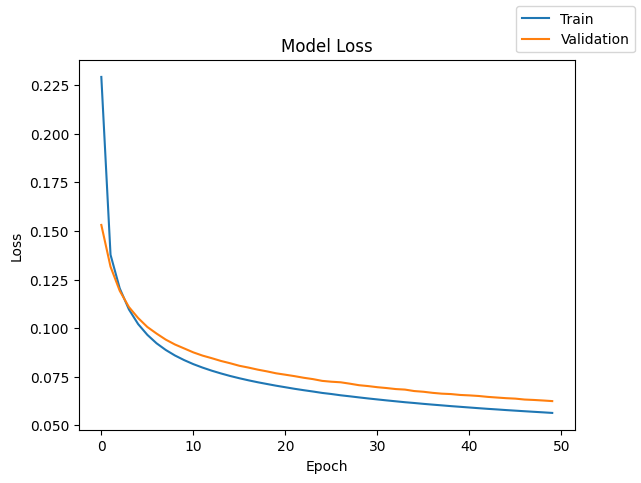

In [54]:
plot(history,'loss')

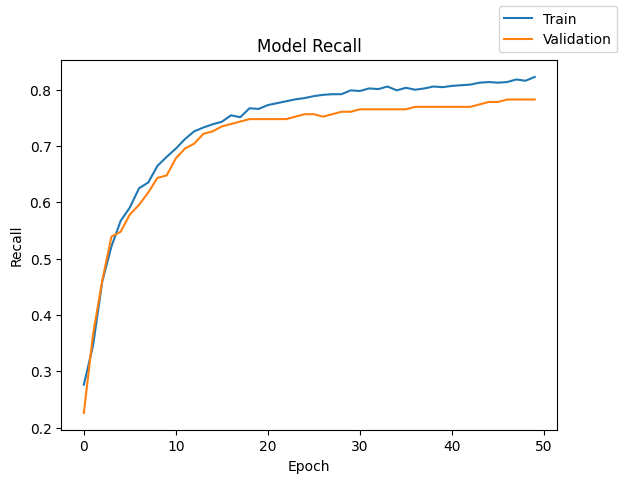

In [55]:
plot(history,'recall')

In [56]:
results.loc[2] = [2,[128, 64],["relu", "relu"],50,32,"sgd",[0.001, "-"],"glorot uniform","-",history.history["loss"][-1],history.history["val_loss"][-1],history.history["recall"][-1],history.history["val_recall"][-1],round(end-start,2)]

In [57]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,[128],[relu],50,32,sgd,"[0.01, -]",glorot uniform,-,0.043810,0.051187,0.861364,0.826087,66.10
1,1,[128],[relu],50,32,sgd,"[0.001, -]",glorot uniform,-,0.065645,0.071659,0.784091,0.765217,89.23
2,2,"[128, 64]","[relu, relu]",50,32,sgd,"[0.001, -]",glorot uniform,-,0.056438,0.062520,0.822727,0.782609,97.02


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


<Axes: ylabel='Count'>

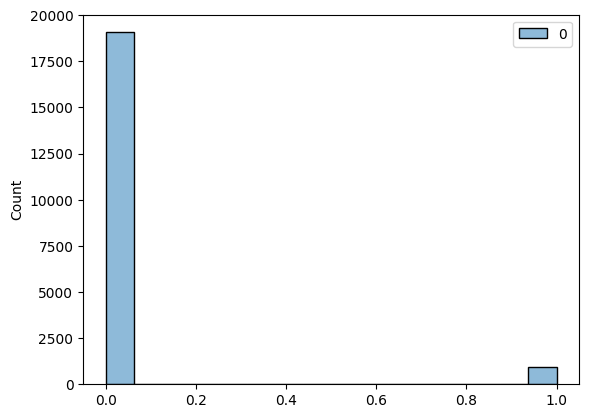

In [58]:
prediction = model_2.predict(X_train)
prediction_rounded = np.round(prediction, decimals = 0)
sns.histplot(prediction_rounded)

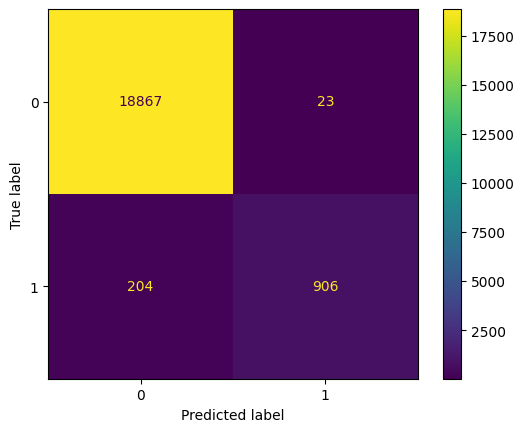

In [59]:
confusion_matrix = metrics.confusion_matrix(y_train, prediction_rounded, labels=[0, 1])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

Observations:
1) Although the model has improved we would still consider it to be in the underfit zone since out base model had a better recall score and the validation loss is still on a downward trend.

## Model 3

Adding Momentum

In [60]:
mom = 0.5

In [61]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [62]:
#Initializing the neural network
model_3 = Sequential()
model_3.add(Dense(128,activation="relu",input_dim = X_train.shape[1]))
model_3.add(Dense(64,activation="relu"))
model_3.add(Dense(num_classes,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
optimizer = keras.optimizers.SGD(learning_rate=learning_rate, momentum=mom)    # defining SGD as the optimizer to be used with momentum
model_3.compile(loss=loss, optimizer=optimizer, metrics=["recall"])

In [65]:
start = time.time()
history = model_3.fit(X_train, y_train, validation_split = 0.2 , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2057 - recall: 0.2807 - val_loss: 0.1377 - val_recall: 0.3870
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1229 - recall: 0.4068 - val_loss: 0.1168 - val_recall: 0.4826
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1061 - recall: 0.5136 - val_loss: 0.1046 - val_recall: 0.5652
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0959 - recall: 0.5932 - val_loss: 0.0965 - val_recall: 0.6087
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0889 - recall: 0.6375 - val_loss: 0.0909 - val_recall: 0.6348
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0840 - recall: 0.6784 - val_loss: 0.0866 - val_recall: 0.6565
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0802 - recall: 0.6989 - val_loss: 0.0834 - val_recall: 0.6696
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0772 - recall: 0.7114 - val_loss: 0.0803 - val_recall: 0.6957
Epoch 9/

In [66]:
print("Time taken in seconds ",end-start)

Time taken in seconds  75.78578090667725


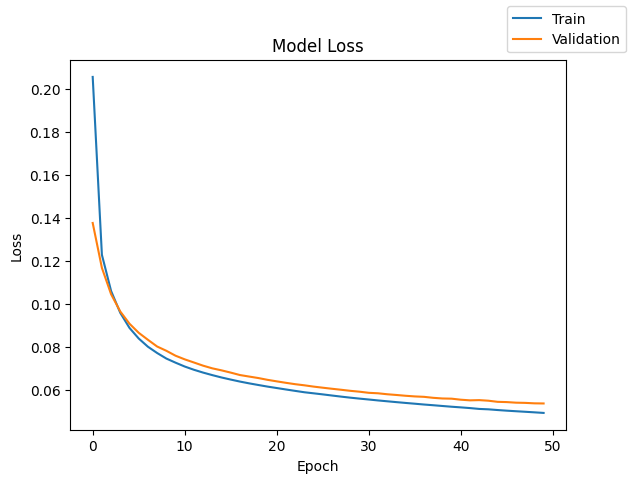

In [67]:
plot(history,'loss')

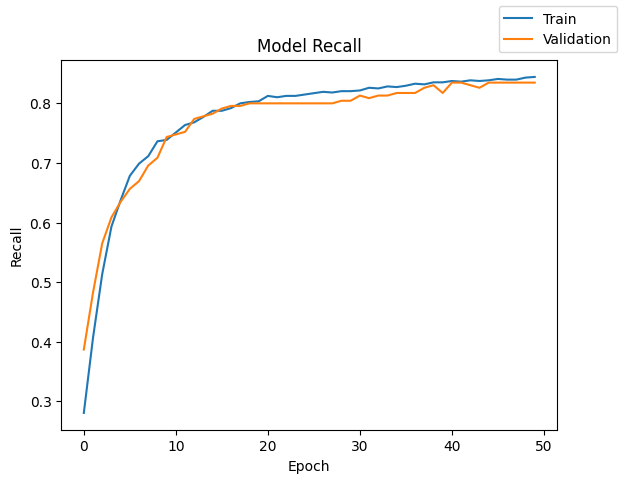

In [68]:
plot(history,'recall')

In [69]:
results.loc[3] = [2,[128, 64],["relu", "relu"],50,32,"sgd with momentum",[0.001, 0.5],"glorot uniform","-",history.history["loss"][-1],history.history["val_loss"][-1],history.history["recall"][-1],history.history["val_recall"][-1],round(end-start,2)]

In [70]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,[128],[relu],50,32,sgd,"[0.01, -]",glorot uniform,-,0.043810,0.051187,0.861364,0.826087,66.10
1,1,[128],[relu],50,32,sgd,"[0.001, -]",glorot uniform,-,0.065645,0.071659,0.784091,0.765217,89.23
2,2,"[128, 64]","[relu, relu]",50,32,sgd,"[0.001, -]",glorot uniform,-,0.056438,0.062520,0.822727,0.782609,97.02
3,2,"[128, 64]","[relu, relu]",50,32,sgd with momentum,"[0.001, 0.5]",glorot uniform,-,0.049375,0.053774,0.844318,0.834783,75.79


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


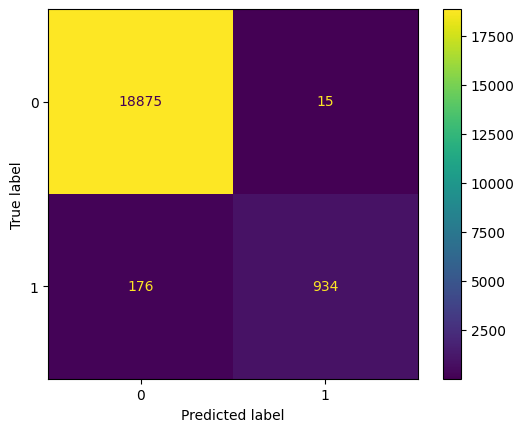

In [71]:
prediction = model_3.predict(X_train)
prediction_rounded = np.round(prediction, decimals = 0)
confusion_matrix = metrics.confusion_matrix(y_train, prediction_rounded, labels=[0, 1])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

Observations:
1) SGD with momentum has improved the model considerably and it has a better recall score than the base model on the validation set.
2) The base model has a better recall on training set so that implies Model 3 is more generalisable than the base model.

## Model 4

The following improvement for Model 4
1) Use Adam as the optimiser since this will have SGD with momentum and at the same time have an adaptive gradient.


In [72]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [73]:
#Initializing the neural network
model_4 = Sequential()
model_4.add(Dense(128,activation="relu",input_dim = X_train.shape[1]))
model_4.add(Dense(64,activation="relu"))
model_4.add(Dense(num_classes,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)    # defining SGD as the optimizer to be used with momentum
model_4.compile(loss=loss, optimizer=optimizer, metrics=["recall"])

In [76]:
start = time.time()
history = model_4.fit(X_train, y_train, validation_split = 0.2 , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0779 - recall: 0.7466 - val_loss: 0.0574 - val_recall: 0.8087
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0544 - recall: 0.8364 - val_loss: 0.0530 - val_recall: 0.8478
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0476 - recall: 0.8602 - val_loss: 0.0545 - val_recall: 0.8304
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0453 - recall: 0.8659 - val_loss: 0.0485 - val_recall: 0.8783
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0419 - recall: 0.8739 - val_loss: 0.0480 - val_recall: 0.8652
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0392 - recall: 0.8818 - val_loss: 0.0495 - val_recall: 0.8739
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0398 - recall: 0.8807 - val_loss: 0.0459 - val_recall: 0.8696
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0369 - recall: 0.8909 - val_loss: 0.0534 - val_recall: 0.8391
Epoch 9/

In [77]:
print("Time taken in seconds ",end-start)

Time taken in seconds  112.16707587242126


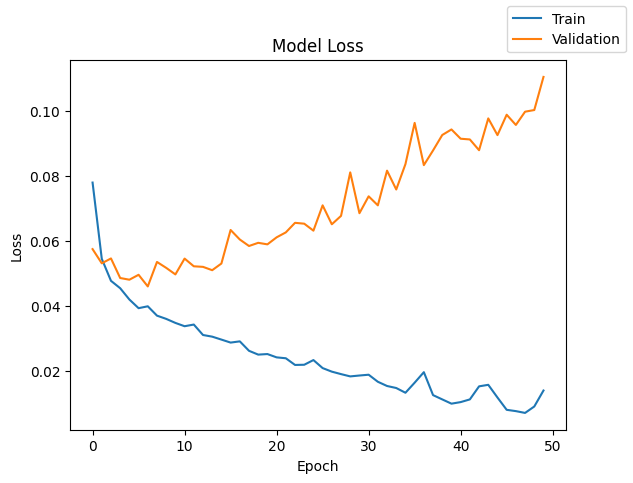

In [78]:
plot(history,'loss')

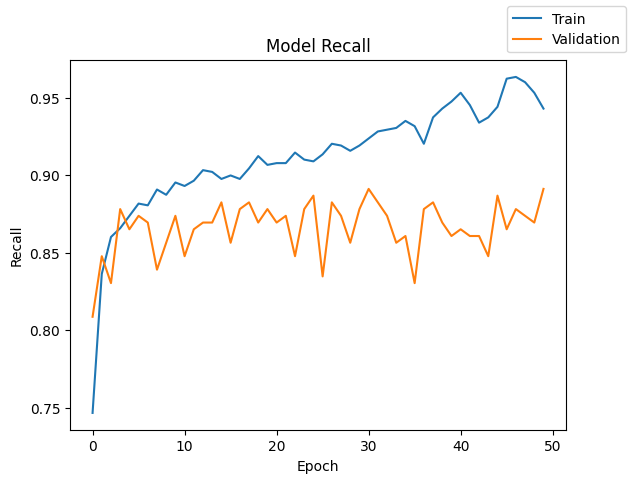

In [79]:
plot(history,'recall')

In [80]:
results.loc[4] = [2,[128, 64],["relu", "relu"],50,32,"adam",[0.001, "-"],"glorot uniform","-",history.history["loss"][-1],history.history["val_loss"][-1],history.history["recall"][-1],history.history["val_recall"][-1],round(end-start,2)]

In [81]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,[128],[relu],50,32,sgd,"[0.01, -]",glorot uniform,-,0.043810,0.051187,0.861364,0.826087,66.10
1,1,[128],[relu],50,32,sgd,"[0.001, -]",glorot uniform,-,0.065645,0.071659,0.784091,0.765217,89.23
2,2,"[128, 64]","[relu, relu]",50,32,sgd,"[0.001, -]",glorot uniform,-,0.056438,0.062520,0.822727,0.782609,97.02
3,2,"[128, 64]","[relu, relu]",50,32,sgd with momentum,"[0.001, 0.5]",glorot uniform,-,0.049375,0.053774,0.844318,0.834783,75.79
4,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,-,0.013840,0.110415,0.943182,0.891304,112.17


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


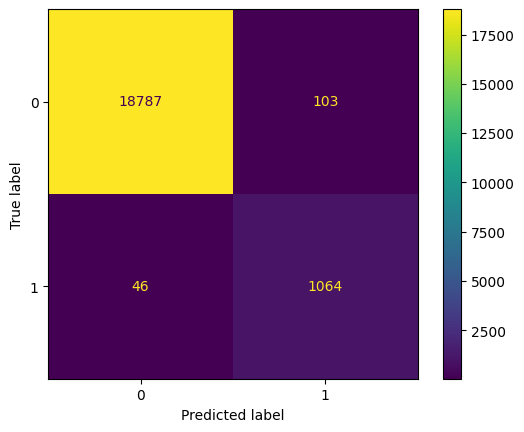

In [82]:
prediction = model_4.predict(X_train)
prediction_rounded = np.round(prediction, decimals = 0)
confusion_matrix = metrics.confusion_matrix(y_train, prediction_rounded, labels=[0, 1])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

Observations:
The Recall has improved significantly but there is a divergence between train recall and validation recall. The validation loss function kept increasing with each epoch which suggests that it is overfit. To reduce overfitting we could consider regularization.

## Model 5

Adding
1) Dropout rate for regularization.


In [83]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [84]:
dropout_rate = 0.5

In [85]:
#Initializing the neural network
model_5 = Sequential()
model_5.add(Dense(128,activation="relu",input_dim = X_train.shape[1]))
model_5.add(Dropout(dropout_rate))
model_5.add(Dense(64,activation="relu"))
model_5.add(Dropout(dropout_rate))
model_5.add(Dense(num_classes,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)    # defining SGD as the optimizer to be used with momentum
model_5.compile(loss=loss, optimizer=optimizer, metrics=["recall"])

In [88]:
start = time.time()
history = model_5.fit(X_train, y_train, validation_split = 0.2 , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1824 - recall: 0.3955 - val_loss: 0.0874 - val_recall: 0.6348
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1080 - recall: 0.6250 - val_loss: 0.0725 - val_recall: 0.7478
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0886 - recall: 0.6977 - val_loss: 0.0673 - val_recall: 0.7478
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0783 - recall: 0.7489 - val_loss: 0.0637 - val_recall: 0.7870
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0755 - recall: 0.7523 - val_loss: 0.0596 - val_recall: 0.8087
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0716 - recall: 0.7648 - val_loss: 0.0579 - val_recall: 0.8043
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0690 - recall: 0.7852 - val_loss: 0.0536 - val_recall: 0.8043
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0667 - recall: 0.7955 - val_loss: 0.0534 - val_recall: 0.8174
Epoch 9/

In [89]:
print("Time taken in seconds ",end-start)

Time taken in seconds  105.08558416366577


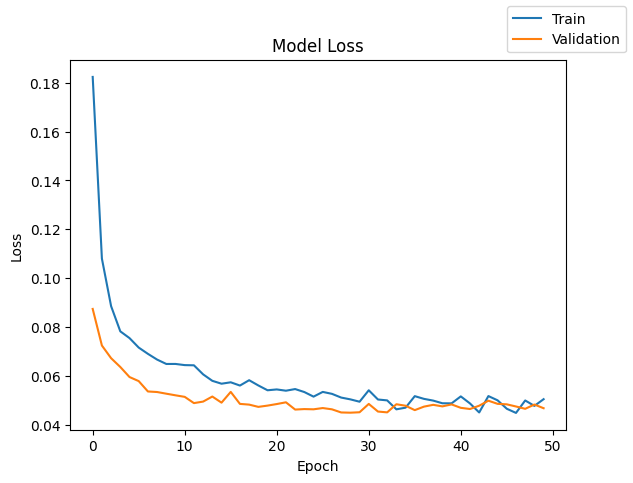

In [90]:
plot(history,'loss')

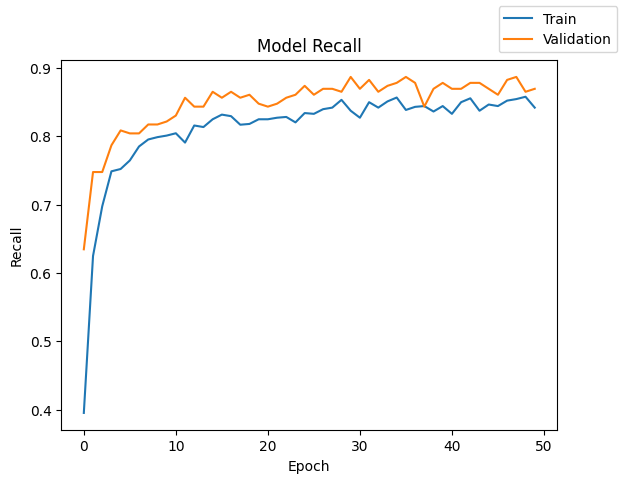

In [91]:
plot(history,'recall')

In [92]:
results.loc[5] = [2,[128, 64],["relu", "relu"],50,32,"adam",[0.001, "-"],"glorot uniform","dropout rate = 0.5",history.history["loss"][-1],history.history["val_loss"][-1],history.history["recall"][-1],history.history["val_recall"][-1],round(end-start,2)]

In [93]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,[128],[relu],50,32,sgd,"[0.01, -]",glorot uniform,-,0.043810,0.051187,0.861364,0.826087,66.10
1,1,[128],[relu],50,32,sgd,"[0.001, -]",glorot uniform,-,0.065645,0.071659,0.784091,0.765217,89.23
2,2,"[128, 64]","[relu, relu]",50,32,sgd,"[0.001, -]",glorot uniform,-,0.056438,0.062520,0.822727,0.782609,97.02
3,2,"[128, 64]","[relu, relu]",50,32,sgd with momentum,"[0.001, 0.5]",glorot uniform,-,0.049375,0.053774,0.844318,0.834783,75.79
4,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,-,0.013840,0.110415,0.943182,0.891304,112.17
5,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,dropout rate = 0.5,0.050491,0.046788,0.842045,0.869565,105.09


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


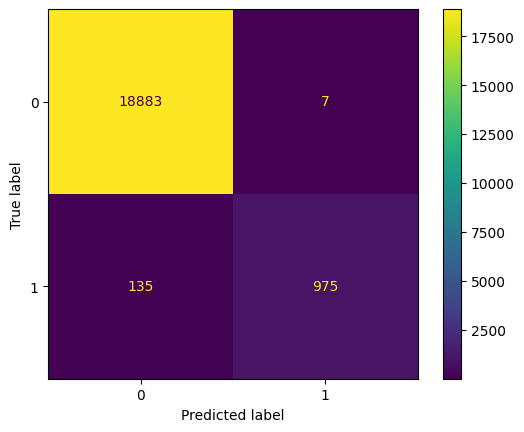

In [94]:
prediction = model_5.predict(X_train)
prediction_rounded = np.round(prediction, decimals = 0)
confusion_matrix = metrics.confusion_matrix(y_train, prediction_rounded, labels=[0, 1])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

The difference between train and validation recall has reduced. In fact the validation recall is higher so we can conclude that the model is no longer overfit. Model 5 also has the highest validation recall excluding Model 4 which was overfit.

## Model 6

Adding Batch normalization

In [95]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [96]:
#Initializing the neural network
model_6 = Sequential()
model_6.add(Dense(128,activation="relu",input_dim = X_train.shape[1]))
model_6.add(BatchNormalization())
model_6.add(Dropout(dropout_rate))
model_6.add(Dense(64,activation="relu"))
model_6.add(BatchNormalization())
model_6.add(Dropout(dropout_rate))
model_6.add(Dense(num_classes,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [97]:
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 13,953 (54.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [98]:
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)    # defining SGD as the optimizer to be used with momentum
model_6.compile(loss=loss, optimizer=optimizer, metrics=["recall"])

In [99]:
start = time.time()
history = model_6.fit(X_train, y_train, validation_split = 0.2 , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3684 - recall: 0.5693 - val_loss: 0.0824 - val_recall: 0.6304
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1317 - recall: 0.5477 - val_loss: 0.0690 - val_recall: 0.6696
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1012 - recall: 0.6250 - val_loss: 0.0630 - val_recall: 0.7087
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0888 - recall: 0.6693 - val_loss: 0.0573 - val_recall: 0.7522
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0859 - recall: 0.6784 - val_loss: 0.0562 - val_recall: 0.7609
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0757 - recall: 0.7057 - val_loss: 0.0572 - val_recall: 0.7609
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0716 - recall: 0.7295 - val_loss: 0.0515 - val_recall: 0.8130
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0717 - recall: 0.7466 - val_loss: 0.0511 - val_recall: 0.7913
Epoch 9/

In [100]:
print("Time taken in seconds ",end-start)

Time taken in seconds  122.01524353027344


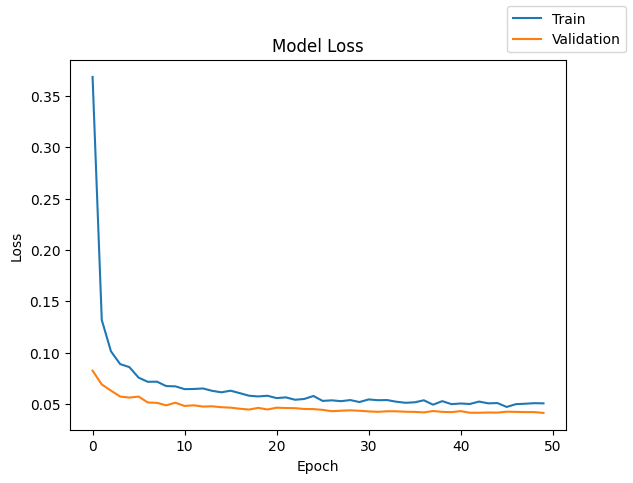

In [101]:
plot(history,'loss')

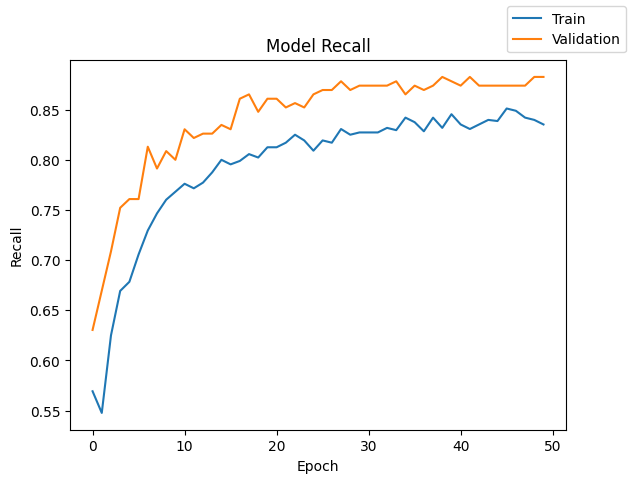

In [102]:
plot(history,'recall')

In [103]:
results.loc[6] = [2,[128, 64],["relu", "relu"],50,32,"adam",[0.001, "-"],"glorot uniform","dropout rate = 0.5 and Batch Normalization",history.history["loss"][-1],history.history["val_loss"][-1],history.history["recall"][-1],history.history["val_recall"][-1],round(end-start,2)]

In [104]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,[128],[relu],50,32,sgd,"[0.01, -]",glorot uniform,-,0.043810,0.051187,0.861364,0.826087,66.10
1,1,[128],[relu],50,32,sgd,"[0.001, -]",glorot uniform,-,0.065645,0.071659,0.784091,0.765217,89.23
2,2,"[128, 64]","[relu, relu]",50,32,sgd,"[0.001, -]",glorot uniform,-,0.056438,0.062520,0.822727,0.782609,97.02
3,2,"[128, 64]","[relu, relu]",50,32,sgd with momentum,"[0.001, 0.5]",glorot uniform,-,0.049375,0.053774,0.844318,0.834783,75.79
4,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,-,0.013840,0.110415,0.943182,0.891304,112.17
5,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,dropout rate = 0.5,0.050491,0.046788,0.842045,0.869565,105.09
6,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,dropout rate = 0.5 and Batch Normalization,0.050631,0.041319,0.835227,0.882609,122.02


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


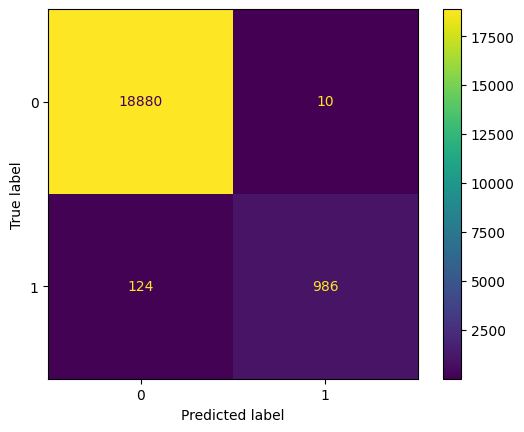

In [105]:
prediction = model_6.predict(X_train)
prediction_rounded = np.round(prediction, decimals = 0)
confusion_matrix = metrics.confusion_matrix(y_train, prediction_rounded, labels=[0, 1])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

Adding batch normalization has further improved the model and this model has the fewest false negatives within the whole of train dataset.

## Model 7

Since the model is still underfit, we can consider improving the complexity of the model to see if that improves the recall. We add an additional layer to see how far the performance has improved.

In [106]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [107]:
#Initializing the neural network
model_7 = Sequential()
model_7.add(Dense(128,activation="relu",input_dim = X_train.shape[1]))
model_7.add(BatchNormalization())
model_7.add(Dropout(dropout_rate))
model_7.add(Dense(64,activation="relu"))
model_7.add(BatchNormalization())
model_7.add(Dropout(dropout_rate))
model_7.add(Dense(32,activation="relu"))
model_7.add(BatchNormalization())
model_7.add(Dropout(dropout_rate))
model_7.add(Dense(num_classes,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [108]:
model_7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,065 (62.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [109]:
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)    # defining SGD as the optimizer to be used with momentum
model_7.compile(loss=loss, optimizer=optimizer, metrics=["recall"])

In [110]:
start = time.time()
history = model_7.fit(X_train, y_train, validation_split = 0.2 , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4540 - recall: 0.3898 - val_loss: 0.1317 - val_recall: 0.5783
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1784 - recall: 0.3955 - val_loss: 0.0839 - val_recall: 0.6174
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1342 - recall: 0.4580 - val_loss: 0.0746 - val_recall: 0.6478
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1200 - recall: 0.4955 - val_loss: 0.0673 - val_recall: 0.6652
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1054 - recall: 0.5591 - val_loss: 0.0626 - val_recall: 0.7174
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0984 - recall: 0.5852 - val_loss: 0.0584 - val_recall: 0.7261
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0898 - recall: 0.6261 - val_loss: 0.0560 - val_recall: 0.7870
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0886 - recall: 0.6511 - val_loss: 0.0523 - val_recall: 0.8000
Epoch 9/

In [111]:
print("Time taken in seconds ",end-start)

Time taken in seconds  144.36799001693726


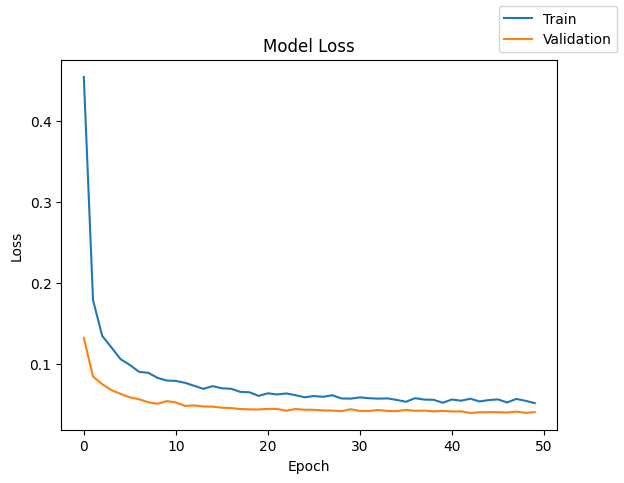

In [112]:
plot(history,'loss')

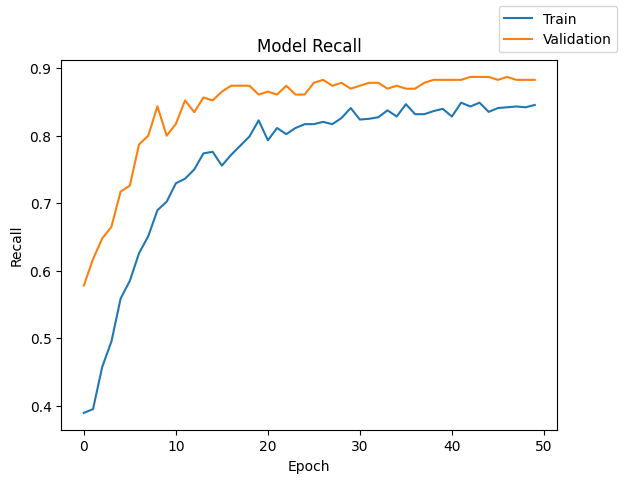

In [113]:
plot(history,'recall')

In [114]:
results.loc[7] = [3,[128, 64, 32],["relu", "relu"],50,32,"adam",[0.001, "-"],"glorot uniform","dropout rate = 0.5 and Batch Normalization",history.history["loss"][-1],history.history["val_loss"][-1],history.history["recall"][-1],history.history["val_recall"][-1],round(end-start,2)]

In [115]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,[128],[relu],50,32,sgd,"[0.01, -]",glorot uniform,-,0.043810,0.051187,0.861364,0.826087,66.10
1,1,[128],[relu],50,32,sgd,"[0.001, -]",glorot uniform,-,0.065645,0.071659,0.784091,0.765217,89.23
2,2,"[128, 64]","[relu, relu]",50,32,sgd,"[0.001, -]",glorot uniform,-,0.056438,0.062520,0.822727,0.782609,97.02
3,2,"[128, 64]","[relu, relu]",50,32,sgd with momentum,"[0.001, 0.5]",glorot uniform,-,0.049375,0.053774,0.844318,0.834783,75.79
4,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,-,0.013840,0.110415,0.943182,0.891304,112.17
5,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,dropout rate = 0.5,0.050491,0.046788,0.842045,0.869565,105.09
6,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,dropout rate = 0.5 and Batch Normalization,0.050631,0.041319,0.835227,0.882609,122.02
7,3,"[128, 64, 32]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,dropout rate = 0.5 and Batch Normalization,0.051171,0.040054,0.845455,0.882609,144.37


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


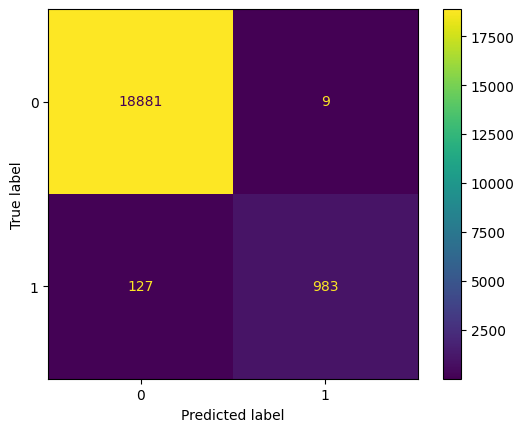

In [116]:
prediction = model_7.predict(X_train)
prediction_rounded = np.round(prediction, decimals = 0)
confusion_matrix = metrics.confusion_matrix(y_train, prediction_rounded, labels=[0, 1])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

The additional layer hasn't improved the validation recall at all. This implies the 3rd layer isn't adding any prediction power to the model. If the performance is similar we should prioritise a model with a lower complexity.

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [118]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,[128],[relu],50,32,sgd,"[0.01, -]",glorot uniform,-,0.043810,0.051187,0.861364,0.826087,66.10
1,1,[128],[relu],50,32,sgd,"[0.001, -]",glorot uniform,-,0.065645,0.071659,0.784091,0.765217,89.23
2,2,"[128, 64]","[relu, relu]",50,32,sgd,"[0.001, -]",glorot uniform,-,0.056438,0.062520,0.822727,0.782609,97.02
3,2,"[128, 64]","[relu, relu]",50,32,sgd with momentum,"[0.001, 0.5]",glorot uniform,-,0.049375,0.053774,0.844318,0.834783,75.79
4,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,-,0.013840,0.110415,0.943182,0.891304,112.17
5,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,dropout rate = 0.5,0.050491,0.046788,0.842045,0.869565,105.09
6,2,"[128, 64]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,dropout rate = 0.5 and Batch Normalization,0.050631,0.041319,0.835227,0.882609,122.02
7,3,"[128, 64, 32]","[relu, relu]",50,32,adam,"[0.001, -]",glorot uniform,dropout rate = 0.5 and Batch Normalization,0.051171,0.040054,0.845455,0.882609,144.37


The base model was chosen with 128 neurons since that is appropriate for a dataset with 40 features. The model reaches the minima of the loss function fairly quickly and seems to oscillate. We improve on the base model with the following steps:



1. Reducing the Learing Rate
On reducing the learning rate to 0.001 we see a smoother loss function which looks underfit initially but is promising since that doesnt have any oscillations and could have a stronger prediction power on further optimisations.

2. Additional Layer
Adding one layer clearly improves the performance. This layer has 64 neurons making it a convoluted Neural network. The validation score is still on a downtrend.

3. Adding momentum
Introduction of momentum leads to faster convergence. The loss function decrease rapidly. Although momentum might lead to oscillations we don't observe any of it in this case which confirms that the learning rate is appropriate.

4. Using Adam Optimiser
Adam optimiser will adjust the step size for different parameters and could converge even faster than sgd with momentum. We observe the same when validation loss falls sharply during the first few epochs and eventually starts rising. This implies the model is overfit. Despite being overfit the model has shown better performance on the validation set.

5. Adding droput rate
The dropout rate significantly helps with model overfitting. The train and validation recall are now compareable.

6. Batch normalisation
Adding batch normalisation has made the convergence a lot faster without making the model overfit.

7. Adding a 3rd layer
The 3r layer hasn't improved the model and therefore it is unnecessary.

We conclude the model 6 is the best model for this problem.



Now, let's check the performance of the final model on the test set.

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


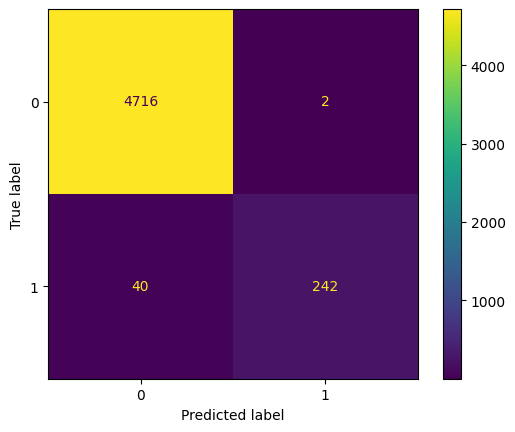

In [119]:
prediction = model_6.predict(X_test)
prediction_rounded = np.round(prediction, decimals = 0)
confusion_matrix = metrics.confusion_matrix(y_test, prediction_rounded, labels=[0, 1])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

As seen in the above confusion matrix, the recall score = (TP)/(TP + FN) = 242/282 = 85.9%.

The performance on test set is similar to that of train and validation set which further confirms that out model isn't overfit.

# **Actionable Insights and Recommendations**

Write down some insights and business recommendations based on your observations.

Model 6 provides a good recall score and can reduce breakage costs
significantly.

Depending on the business needs we can adjust the model's cutoff to reduce the false negatives further. At this point we have used 0.5 as the threshold to see if the prediction is 1 or 0. But if we reduce it to 0.2 we will have more false postives and fewer false negatives.

This seems like a good idea since we only got 2 false postives on the test set.



